# Notebook 03: Activation Patching & MLP Ablation

**Research Question:** Which downstream MLP circuits fail to translate 
L1H1's correct modifier attention into correct repetition counts, and 
can patching activations from success cases into failure cases restore 
correct behavior?

**Background from Notebook 02:**
- L0H0 is the primary modifier-tracking head
- Modifier attention is preserved in failure cases
- Failure is downstream of attention

**Hypotheses:**
- H4: Ablating L0H0 increases failure rate 
  (confirms modifier tracking role)
- H5: Patching L0 MLP activations from success → failure cases 
  restores correct repetition counts
- H6: L0 MLP is the primary circuit responsible for translating 
  modifier attention into repetition counts

**Dependencies & Setup**

In [11]:
import sys, os
root_path = os.path.abspath("..")
src_path = os.path.join(root_path, "src")
for path in [root_path, src_path]:
    if path not in sys.path:
        sys.path.append(root_path)
import re
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from jaxtyping import Float, Int
from torch import Tensor
import circuitsvis as cv
from transformer_lens import HookedTransformer, HookedTransformerConfig

from config.config import Config
from src.data import SCANDataModule,SCANTokenizer
from src.model import Transformer
from src.evaluate import Evaluator

## 1. Setup & Load Model

In [12]:
cfg = Config()
model = Transformer(cfg)
model.load_state_dict(torch.load("../results/model_seed42.pt")) # Use Seed 42 Model
seeds = cfg.seeds
primary_seed = seeds[0]

dm = SCANDataModule(cfg)
tokenizer = dm.tokenizer

In [13]:
def parse_failure_log(filepath):
    """
    Parses SCAN failure logs and returns a list of dictionaries 
    with columns: splitname, command, target, pred.
    """
    # Regex breakdown:
    # \[(.*?)\] -> Captures everything inside the square brackets (splitname)
    # COMMAND:.*?IN:\s*(.*?)\s*OUT: -> Captures everything between IN: and OUT: (command)
    # TARGET:\s*(.*?)\s*\| -> Captures everything between TARGET: and the next | (target)
    # PRED:\s*(.*)$ -> Captures everything after PRED: to the end of the line (pred)
    pattern = re.compile(r"\[(.*?)\]\s*COMMAND:\s*(.*?)\s*\|\s*TARGET:\s*(.*?)\s*\|\s*PRED:\s*(.*)$")
    
    parsed_rows = []
    
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue  # Skip empty lines
                
            match = pattern.search(line)
            if match:
                splitname, command, target, pred = match.groups()
                
                parsed_rows.append({
                    "splitname": splitname,
                    "command": command.strip(),
                    "target": target.strip(),
                    "pred": pred.strip()
                })
                
    return parsed_rows

In [14]:
def load_tl_model_for_seed(seed: int, hooked_cfg, checkpoint_dir: str = "../results") -> HookedTransformer:
    """
    Load a fresh HookedTransformer with weights from a specific seed's
    checkpoint, porting from the custom Transformer state dict format.
    """
    tl_model = HookedTransformer(hooked_cfg)
    custom_state_dict = torch.load(f"{checkpoint_dir}/model_seed{seed}.pt")

    tl_state_dict = {}
    keys_to_skip = ["tfblocks.0.attn.IGNORE", "tfblocks.1.attn.IGNORE"]

    for key, weight in custom_state_dict.items():
        if key in keys_to_skip:
            continue
        new_key = key
        if new_key.startswith("tfblocks."):
            new_key = new_key.replace("tfblocks.", "blocks.")
        if new_key.startswith("ln."):
            new_key = new_key.replace("ln.", "ln_final.")
        if new_key == "embed.token_embed.weight":
            new_key = "embed.W_E"
        if new_key == "embed.pos_emb.weight":
            new_key = "pos_embed.W_pos"
        tl_state_dict[new_key] = weight

    missing_keys, unexpected_keys = tl_model.load_state_dict(tl_state_dict, strict=False)
    real_missing = [k for k in missing_keys if "mask" not in k and "IGNORE" not in k]

    assert len(real_missing) == 0, f"Seed {seed}: unexpected missing keys {real_missing}"
    assert len(unexpected_keys) == 0, f"Seed {seed}: unexpected keys {unexpected_keys}"

    return tl_model

In [15]:
def verify_seed_reproduces_failures(tl_model, failure_df: pd.DataFrame, dm, cfg, seed: int) -> None:
    """
    Sanity check: confirm tl_model's weights actually reproduce the
    logged failure it's supposed to explain for this seed.
    """
    sample_case = failure_df.iloc[0]
    sample_pred = generate(tl_model, sample_case["command"], dm, cfg)
    assert sample_pred.strip() == sample_case["pred"].strip(), (
        f"Seed {seed}: tl_model does not reproduce its own logged "
        f"failure. Weight loading likely mismatched."
    )

In [16]:
for seed in seeds:
    simple_data = parse_failure_log(f"../results/failure_cases/failure_cases_simple_seed{seed}.txt")
    length_data = parse_failure_log(f"../results/failure_cases/failure_cases_length_seed{seed}.txt")
    addprim_jump_data = parse_failure_log(f"../results/failure_cases/failure_cases_addprim_jump_seed{seed}.txt")

    globals()[f"simple_data_seed{seed}"] = simple_data
    globals()[f"length_data_seed{seed}"] = length_data
    globals()[f"addprim_jump_data_seed{seed}"] = addprim_jump_data

    globals()[f"all_failures_seed{seed}"] = pd.DataFrame(simple_data + length_data + addprim_jump_data)
    globals()[f"simple_failures_seed{seed}"] = pd.DataFrame(simple_data)
    globals()[f"length_failures_seed{seed}"] = pd.DataFrame(length_data)
    globals()[f"addprim_jump_failures_seed{seed}"] = pd.DataFrame(addprim_jump_data)

In [17]:
hooked_cfg = HookedTransformerConfig(
    n_layers=2,
    n_heads=4,
    d_model=128,       
    d_head=32,          
    d_mlp=512,        
    d_vocab= 25,
    n_ctx=128,          
    act_fn="gelu",      
    normalization_type="LN",
) 

tl_model = HookedTransformer(hooked_cfg)
# Load original custom weights
custom_state_dict = torch.load("../results/model_seed42.pt")

# Build a state dict for TransformerLens
tl_state_dict = {}

# Keep track of IGNORE keys
keys_to_skip = ["tfblocks.0.attn.IGNORE", "tfblocks.1.attn.IGNORE"]

for key, weight in custom_state_dict.items():
    if key in keys_to_skip:
        continue
        
    new_key = key
    
    # Map the layer block prefix: "tfblocks.0..." -> "blocks.0..."
    if new_key.startswith("tfblocks."):
        new_key = new_key.replace("tfblocks.", "blocks.")
        
    # Map the final layer norm: "ln.w" -> "ln_final.w"
    if new_key.startswith("ln."):
        new_key = new_key.replace("ln.", "ln_final.")
        
    # Map token embeddings: "embed.token_embed.weight" -> "embed.W_E"
    if new_key == "embed.token_embed.weight":
        new_key = "embed.W_E"
        
    # Map positional embeddings: "embed.pos_emb.weight" -> "pos_embed.W_pos"
    if new_key == "embed.pos_emb.weight":
        new_key = "pos_embed.W_pos"
        
    tl_state_dict[new_key] = weight

# Handle TransformerLens internal tracking values
# TransformerLens has a couple of default buffers (like mask strings) it initializes itself.
# We set strict=False so it doesn't crash over its own missing 'mask' or 'IGNORE' keys.
missing_keys, unexpected_keys = tl_model.load_state_dict(tl_state_dict, strict=False)

# Verify the load was clean
print("Missing keys:", [k for k in missing_keys if "mask" not in k and "IGNORE" not in k])
print("Unexpected keys:", unexpected_keys)

Missing keys: []
Unexpected keys: []


## 2. Baseline Metrics
**Goal:** Establish baseline failure rates before any intervention.

**Output:** Baseline accuracy per split, failure rate per head.

In [18]:
def generate(
    model: HookedTransformer,
    command: str,
    dm: SCANDataModule,
    cfg: Config,
    max_new_tokens: int = 100
) -> str:
    """Generate action sequence autoregressively using HookedTransformer."""
    input_ids = torch.tensor(
        dm.tokenizer.encode(command),
        dtype=torch.long
    ).unsqueeze(0).to(cfg.device)
    
    pred_ids = []
    with torch.no_grad():
        for _ in range(max_new_tokens):
            input_truncated = input_ids[:, -cfg.max_seq_len:]
            logits = model(input_truncated)
            next_token = torch.argmax(logits[:, -1, :], dim=-1)
            if next_token.item() == dm.tokenizer.token2id["<eos>"]:
                break
            pred_ids.append(next_token.item())
            input_ids = torch.cat(
                [input_ids, next_token.unsqueeze(-1)], dim=-1
            )
    return dm.tokenizer.decode(pred_ids)

In [19]:
def compute_baseline_metrics(
    model: HookedTransformer,
    cases: pd.DataFrame,
    dm: SCANDataModule,
    cfg: Config
) -> dict[str, float]:
    """
    Compute baseline accuracy before any intervention.

    Parameters
    ----------
    model : HookedTransformer
        Loaded model.
    cases : pd.DataFrame
        Test cases to evaluate.
    dm : SCANDataModule
        Data module with tokenizer.
    cfg : Config
        Configuration object.

    Returns
    -------
    dict[str, float]
        Dictionary with keys: accuracy, failure_rate, avg_loss
    """

    correct = 0
    total = 0
    total_loss = []
    
    for _, case in cases.iterrows():
        # Generate using model parameter
        pred = generate(model, case["command"], dm, cfg)
        
        if pred.strip() == case["target"].strip():
            correct += 1
        total += 1
        
        # Compute loss
        full_sequence = case["command"] + " " + case["target"]
        tokens = dm.tokenizer.encode(full_sequence)
        token_ids = torch.tensor(tokens).unsqueeze(0).to(cfg.device)
        
        with torch.no_grad():
            logits = model(token_ids)
            loss = torch.nn.functional.cross_entropy(
                logits[:, :-1, :].reshape(-1, logits.shape[-1]),
                token_ids[:, 1:].reshape(-1)
            )
            total_loss.append(loss.item())
    
    return {
        "accuracy": correct / total,
        "failure_rate": 1 - correct / total,
        "avg_loss": torch.tensor(total_loss).mean().item()
    }

## 3. L0H0 Ablation Experiment
**Goal:** Test H4 - does ablating L0H0 increase failure rate?

**Method:** Zero out L0H0's output using TransformerLens hooks. This removes its modifier-tracking signal.
- If failure rate increases → L0H0 is causally important.
- If failure rate stays same → L0H0 is not causally important.

**Output:** Failure rate before vs after ablation.

In [47]:
from functools import partial
from transformer_lens import utils

def ablate_head(
    model: HookedTransformer,
    layer: int,
    head: int | None,
    token_ids: Int[Tensor, "1 seq_len"],
    cfg: Config
) -> Float[Tensor, "seq_len vocab_size"]:
    """
    Zero out a specific attention head, or the entire layer's attention
    output if head=None, and return logits.

    Parameters
    ----------
    model : HookedTransformer
        Loaded model.
    layer : int
        Layer index to ablate.
    head : int | None
        Head index to ablate. If None, all heads in this layer are
        zeroed (whole-layer ablation).
    token_ids : Int[Tensor, "1 seq_len"]
        Tokenized input sequence.
    cfg : Config
        Configuration object.

    Returns
    -------
    Float[Tensor, "seq_len vocab_size"]
        Logits after ablation.
    """
    def hook_fn(value, hook, head_idx):
        # value shape: [batch, seq_len, n_heads, d_head]
        if head_idx is None:
            value[:, :, :, :] = 0.0  # zero all heads in this layer
        else:
            value[:, :, head_idx, :] = 0.0  # zero one specific head
        return value

    with torch.no_grad():
        logits = model.run_with_hooks(
            token_ids,
            fwd_hooks=[(
                utils.get_act_name("z", layer),
                partial(hook_fn, head_idx=head)
            )]
        )
    return logits

def run_ablation_experiment(
    model: HookedTransformer,
    failure_cases: pd.DataFrame,
    layer: int,
    head: int,
    dm: SCANDataModule,
    cfg: Config,
    baseline: dict[str, float] | None = None,
) -> dict[str, float]:
    """
    Run ablation experiment on all failure cases.

    Parameters
    ----------
    baseline : dict[str, float], optional
        Precomputed baseline metrics (from compute_baseline_metrics).
        If None, computed internally. Passing a precomputed baseline
        avoids redundant generation passes and guarantees the baseline
        used for delta matches the one reported alongside it.
    """
    if baseline is None:
        baseline = compute_baseline_metrics(model, failure_cases, dm, cfg)

    correct_ablated = 0
    total = 0

    for _, case in failure_cases.iterrows():
        tokens = dm.tokenizer.encode(case["command"])
        token_ids = torch.tensor(tokens).unsqueeze(0).to(cfg.device)

        pred_ids = []
        input_ids = token_ids.clone()

        with torch.no_grad():
            for _ in range(100):
                input_truncated = input_ids[:, -cfg.max_seq_len:]
                logits = ablate_head(model, layer, head, input_truncated, cfg)
                next_token = torch.argmax(logits[:, -1, :], dim=-1)
                if next_token.item() == dm.tokenizer.token2id["<eos>"]:
                    break
                pred_ids.append(next_token.item())
                input_ids = torch.cat(
                    [input_ids, next_token.unsqueeze(-1)], dim=-1
                )
        pred = dm.tokenizer.decode(pred_ids)
        if pred.strip() == case["target"].strip():
            correct_ablated += 1
        total += 1

    ablated_accuracy = correct_ablated / total
    delta = baseline["accuracy"] - ablated_accuracy
    return {
        "baseline_accuracy": baseline["accuracy"],
        "ablated_accuracy": ablated_accuracy,
        "delta": delta # positive means ablation hurts performance
    } 

In [ ]:
import os
import json
import numpy as np

os.makedirs("../results/ablation", exist_ok=True)

cross_seed_results = []

for seed in seeds:
    print("=" * 60)
    print(f"BASELINE METRICS FOR SEED {seed}")
    print("=" * 60)

    tl_model = load_tl_model_for_seed(seed, hooked_cfg)

    simple_failures = globals()[f"simple_failures_seed{seed}"]

    # Sanity check: confirm this seed's tl_model actually reproduces
    # its own logged failures before trusting any downstream numbers
    verify_seed_reproduces_failures(tl_model, simple_failures, dm, cfg, seed)

    print("\nComputing baseline on simple failures...")
    simple_baseline = compute_baseline_metrics(tl_model, simple_failures, dm, cfg)
    print(f"Simple  → accuracy: {simple_baseline['accuracy']:.4f} | "
          f"failure_rate: {simple_baseline['failure_rate']:.4f} | "
          f"avg_loss: {simple_baseline['avg_loss']:.4f}")

    # Baseline accuracy on logged failure cases should be ~0% by
    # construction (deterministic greedy decoding on the same weights
    # that produced these failure logs). A meaningfully nonzero value
    # is a red flag for weight-loading mismatch on this seed.
    if simple_baseline["accuracy"] > 0.05:
        print(f"WARNING: baseline accuracy {simple_baseline['accuracy']:.2%} "
              f"is unexpectedly high for seed {seed} — check weight loading.")

    print("\nRunning L0H0 ablation on simple failures...")
    simple_ablation = run_ablation_experiment(
        tl_model, simple_failures, layer=0, head=0, dm=dm, cfg=cfg,
        baseline=simple_baseline,  # reuse, don't recompute
    )

    print(f"Simple  → baseline: {simple_ablation['baseline_accuracy']:.4f} | "
          f"ablated: {simple_ablation['ablated_accuracy']:.4f} | "
          f"delta: {simple_ablation['delta']:.4f}")

    cross_seed_results.append({
        "seed": seed,
        "baseline_accuracy": simple_ablation["baseline_accuracy"],
        "ablated_accuracy": simple_ablation["ablated_accuracy"],
        "delta": simple_ablation["delta"],
    })

# Save per-seed results
with open("../results/ablation/cross_seed_summary_simple_L0H0.json", "w") as f:
    json.dump(cross_seed_results, f, indent=2)

# Aggregate across seeds
deltas = [r["delta"] for r in cross_seed_results]
print(f"\n{'='*60}")
print(f"L0H0 ablation delta across {len(seeds)} seeds: "
      f"{np.mean(deltas):.4f} ± {np.std(deltas):.4f}")
print(f"{'='*60}")

BASELINE METRICS FOR SEED 42

Computing baseline on simple failures...
Simple  → accuracy: 0.0000 | failure_rate: 1.0000 | avg_loss: 0.6557

Running L0H0 ablation on simple failures...
Simple  → baseline: 0.0000 | ablated: 0.0015 | delta: -0.0015
BASELINE METRICS FOR SEED 101

Computing baseline on simple failures...
Simple  → accuracy: 0.0003 | failure_rate: 0.9997 | avg_loss: 0.6597

Running L0H0 ablation on simple failures...
Simple  → baseline: 0.0003 | ablated: 0.0186 | delta: -0.0182
BASELINE METRICS FOR SEED 345

Computing baseline on simple failures...
Simple  → accuracy: 0.0000 | failure_rate: 1.0000 | avg_loss: 0.6669

Running L0H0 ablation on simple failures...
Simple  → baseline: 0.0000 | ablated: 0.0063 | delta: -0.0063
BASELINE METRICS FOR SEED 2834

Computing baseline on simple failures...
Simple  → accuracy: 0.0000 | failure_rate: 1.0000 | avg_loss: 0.6383

Running L0H0 ablation on simple failures...
Simple  → baseline: 0.0000 | ablated: 0.0519 | delta: -0.0519
BASELINE

In [ ]:
cross_seed_results = []

for seed in seeds:
    print("=" * 60)
    print(f"BASELINE METRICS FOR SEED {seed}")
    print("=" * 60)

    tl_model = load_tl_model_for_seed(seed, hooked_cfg)

    length_failures = globals()[f"length_failures_seed{seed}"]

    # Sanity check: confirm this seed's tl_model actually reproduces
    # its own logged failures before trusting any downstream numbers
    verify_seed_reproduces_failures(tl_model, length_failures, dm, cfg, seed)

    print("\nComputing baseline on length failures...")
    length_baseline = compute_baseline_metrics(tl_model, length_failures, dm, cfg)
    print(f"Length  → accuracy: {length_baseline['accuracy']:.4f} | "
          f"failure_rate: {length_baseline['failure_rate']:.4f} | "
          f"avg_loss: {length_baseline['avg_loss']:.4f}")

    # Baseline accuracy on logged failure cases should be ~0% by
    # construction (deterministic greedy decoding on the same weights
    # that produced these failure logs). A meaningfully nonzero value
    # is a red flag for weight-loading mismatch on this seed.
    if length_baseline["accuracy"] > 0.05:
        print(f"WARNING: baseline accuracy {length_baseline['accuracy']:.2%} "
              f"is unexpectedly high for seed {seed} — check weight loading.")

    print("\nRunning L0H0 ablation on length failures...")
    length_ablation = run_ablation_experiment(
        tl_model, length_failures, layer=0, head=0, dm=dm, cfg=cfg,
        baseline=length_baseline,  # reuse, don't recompute
    )

    print(f"Length  → baseline: {length_ablation['baseline_accuracy']:.4f} | "
          f"ablated: {length_ablation['ablated_accuracy']:.4f} | "
          f"delta: {length_ablation['delta']:.4f}")

    cross_seed_results.append({
        "seed": seed,
        "baseline_accuracy": length_ablation["baseline_accuracy"],
        "ablated_accuracy": length_ablation["ablated_accuracy"],
        "delta": length_ablation["delta"],
    })

# Save per-seed results
with open("../results/ablation/cross_seed_summary_length_L0H0.json", "w") as f:
    json.dump(cross_seed_results, f, indent=2)

# Aggregate across seeds
deltas = [r["delta"] for r in cross_seed_results]
print(f"\n{'='*60}")
print(f"L0H0 ablation delta across {len(seeds)} seeds: "
      f"{np.mean(deltas):.4f} ± {np.std(deltas):.4f}")
print(f"{'='*60}")

In [ ]:
cross_seed_results = []

for seed in seeds:
    print("=" * 60)
    print(f"BASELINE METRICS FOR SEED {seed}")
    print("=" * 60)

    tl_model = load_tl_model_for_seed(seed, hooked_cfg)

    addprim_jump_failures = globals()[f"addprim_jump_failures_seed{seed}"]

    # Sanity check: confirm this seed's tl_model actually reproduces
    # its own logged failures before trusting any downstream numbers
    verify_seed_reproduces_failures(tl_model, addprim_jump_failures, dm, cfg, seed)

    print("\nComputing baseline on addprim_jump failures...")
    addprim_jump_baseline = compute_baseline_metrics(tl_model, addprim_jump_failures, dm, cfg)
    print(f"AddPrim Jump  → accuracy: {addprim_jump_baseline['accuracy']:.4f} | "
          f"failure_rate: {addprim_jump_baseline['failure_rate']:.4f} | "
          f"avg_loss: {addprim_jump_baseline['avg_loss']:.4f}")

    # Baseline accuracy on logged failure cases should be ~0% by
    # construction (deterministic greedy decoding on the same weights
    # that produced these failure logs). A meaningfully nonzero value
    # is a red flag for weight-loading mismatch on this seed.
    if addprim_jump_baseline["accuracy"] > 0.05:
        print(f"WARNING: baseline accuracy {addprim_jump_baseline['accuracy']:.2%} "
              f"is unexpectedly high for seed {seed} — check weight loading.")

    print("\nRunning L0H0 ablation on addprim_jump failures...")
    addprim_jump_ablation = run_ablation_experiment(
        tl_model, addprim_jump_failures, layer=0, head=0, dm=dm, cfg=cfg,
        baseline=addprim_jump_baseline,  # reuse, don't recompute
    )

    print(f"AddPrim Jump  → baseline: {addprim_jump_ablation['baseline_accuracy']:.4f} | "
          f"ablated: {addprim_jump_ablation['ablated_accuracy']:.4f} | "
          f"delta: {addprim_jump_ablation['delta']:.4f}")

    cross_seed_results.append({
        "seed": seed,
        "baseline_accuracy": addprim_jump_ablation["baseline_accuracy"],
        "ablated_accuracy": addprim_jump_ablation["ablated_accuracy"],
        "delta": addprim_jump_ablation["delta"],
    })

# Save per-seed results
with open("../results/ablation/cross_seed_summary_addprim_jump_L0H0.json", "w") as f:
    json.dump(cross_seed_results, f, indent=2)

# Aggregate across seeds
deltas = [r["delta"] for r in cross_seed_results]
print(f"\n{'='*60}")
print(f"L0H0 ablation delta across {len(seeds)} seeds: "
      f"{np.mean(deltas):.4f} ± {np.std(deltas):.4f}")
print(f"{'='*60}")

### 3.1 Layer 0 Ablation Experiment
**Goal:** Test abaltion on the whole L0 to see if its effect on failure rate

**Method:** Zero out Layer 0's output using TransformerLens hooks. This removes its modifier-tracking signal.
- If failure rate increases → L0 is causally important.
- If failure rate stays same → L0 is not causally important.

**Output:** Failure rate before vs after ablation.

In [48]:
os.makedirs("../results/ablation", exist_ok=True)

splits = ["simple", "length", "addprim_jump"]
layer_to_ablate = 0  # whole-Layer-0 ablation

for split in splits:
    cross_seed_results = []

    for seed in seeds:
        tl_model = load_tl_model_for_seed(seed, hooked_cfg)
        failure_df = globals()[f"{split}_failures_seed{seed}"]

        verify_seed_reproduces_failures(tl_model, failure_df, dm, cfg, seed)

        baseline = compute_baseline_metrics(tl_model, failure_df, dm, cfg)
        if baseline["accuracy"] > 0.05:
            print(f"WARNING: baseline accuracy {baseline['accuracy']:.2%} "
                  f"unexpectedly high for seed {seed}, split {split}")

        result = run_ablation_experiment(
            tl_model, failure_df, layer=layer_to_ablate, head=None,
            dm=dm, cfg=cfg, baseline=baseline,
        )

        print(f"[{split}] seed {seed}: baseline={result['baseline_accuracy']:.4f} "
              f"ablated={result['ablated_accuracy']:.4f} delta={result['delta']:.4f}")

        cross_seed_results.append({
            "seed": seed,
            "baseline_accuracy": result["baseline_accuracy"],
            "ablated_accuracy": result["ablated_accuracy"],
            "delta": result["delta"],
        })

    with open(f"../results/ablation/cross_seed_summary_{split}_L0_all_heads.json", "w") as f:
        json.dump(cross_seed_results, f, indent=2)

    deltas = [r["delta"] for r in cross_seed_results]
    print(f"\n[{split}] Whole-Layer-0 ablation delta: "
          f"{np.mean(deltas):.4f} ± {np.std(deltas):.4f}\n")

[simple] seed 42: baseline=0.0000 ablated=0.0000 delta=0.0000
[simple] seed 101: baseline=0.0003 ablated=0.0000 delta=0.0003
[simple] seed 345: baseline=0.0000 ablated=0.0000 delta=0.0000
[simple] seed 2834: baseline=0.0000 ablated=0.0004 delta=-0.0004
[simple] seed 10101: baseline=0.0010 ablated=0.0000 delta=0.0010

[simple] Whole-Layer-0 ablation delta: 0.0002 ± 0.0005

[length] seed 42: baseline=0.0003 ablated=0.0000 delta=0.0003
[length] seed 101: baseline=0.0000 ablated=0.0000 delta=0.0000
[length] seed 345: baseline=0.0000 ablated=0.0000 delta=0.0000
[length] seed 2834: baseline=0.0000 ablated=0.0000 delta=0.0000
[length] seed 10101: baseline=0.0004 ablated=0.0000 delta=0.0004

[length] Whole-Layer-0 ablation delta: 0.0001 ± 0.0002

[addprim_jump] seed 42: baseline=0.0003 ablated=0.0000 delta=0.0003
[addprim_jump] seed 101: baseline=0.0002 ablated=0.0000 delta=0.0002
[addprim_jump] seed 345: baseline=0.0002 ablated=0.0000 delta=0.0002
[addprim_jump] seed 2834: baseline=0.0004 abl

## 4. MLP Activation Patching
**Goal:** Test H5 - does patching L0 MLP activations from success 
cases into failure cases restore correct behavior?

**Method:** 
1. Run model on SUCCESS case → cache L0 MLP output
2. Run model on FAILURE case → patch L0 MLP with success activations
3. Check if patched output is now correct

**Output:** 
- Patch success rate (% of failures fixed by patching)
- Which MLP layer is most effective when patched

In [23]:
def get_mlp_activations(
    model: HookedTransformer,
    token_ids: Int[Tensor, "1 seq_len"],
    layer: int,
    cfg: Config
) -> Float[Tensor, "seq_len d_mlp"]:
    """
    Extract MLP activations for a specific layer.

    Parameters
    ----------
    model : HookedTransformer
        Loaded model.
    token_ids : Int[Tensor, "1 seq_len"]
        Tokenized input sequence.
    layer : int
        Which layer's MLP to extract.
    cfg : Config
        Configuration object.

    Returns
    -------
    Float[Tensor, "seq_len d_mlp"]
        MLP post-activation values.
    """
    logits, cache = model.run_with_cache(token_ids)
    mlp_layer = cache[f"blocks.{layer}.mlp.hook_post"].squeeze(0) # [1, seq_len, d_mlp] to [seq_len. d_mlp]
    return mlp_layer

def get_average_mlp_activations(
    model: HookedTransformer,
    success_cases: pd.DataFrame,
    layer: int,
    dm: SCANDataModule,
    cfg: Config,
    max_len: int = 128
) -> Float[Tensor, "seq_len d_mlp"]:
    """
    Compute average MLP activations across success cases, using the
    FULL sequence (command + target) so generation-phase positions
    are actually represented. Averages only over positions with real
    (non-padding) data, rather than diluting toward zero with padding.
    """
    sum_acts = torch.zeros(max_len, cfg.d_mlp, device=cfg.device)
    count_acts = torch.zeros(max_len, 1, device=cfg.device)

    with torch.no_grad():
        for _, case in success_cases.iterrows():
            full_sequence = case["command"] + " " + case["target"]
            tokens = dm.tokenizer.encode(full_sequence)
            token_ids = torch.tensor(tokens).unsqueeze(0).to(cfg.device)
            acts = get_mlp_activations(model, token_ids, layer, cfg)  # [seq_len, d_mlp]

            usable_len = min(acts.shape[0], max_len)
            sum_acts[:usable_len] += acts[:usable_len]
            count_acts[:usable_len] += 1

    # Positions with zero contributing cases stay 0 (genuinely no data);
    # clamp only to avoid division by zero, not to hide the distinction
    # between "averages to zero" and "no data available"
    avg_acts = sum_acts / count_acts.clamp(min=1)
    return avg_acts

def patch_mlp_activations(
    model: HookedTransformer,
    failure_token_ids: Int[Tensor, "1 seq_len"],
    success_mlp_activations: Float[Tensor, "seq_len d_mlp"],
    layer: int,
    cfg: Config
) -> Float[Tensor, "seq_len vocab_size"]:
    """
    Patch MLP activations from success case into failure case.

    Parameters
    ----------
    model : HookedTransformer
        Loaded model.
    failure_token_ids : Int[Tensor, "1 seq_len"]
        Tokenized failure case input.
    success_mlp_activations : Float[Tensor, "seq_len d_mlp"]
        MLP activations from success case to patch in.
    layer : int
        Which MLP layer to patch.
    cfg : Config
        Configuration object.

    Returns
    -------
    Float[Tensor, "seq_len vocab_size"]
        Logits after patching.
    """
    prompt_len = success_mlp_activations.shape[0]

    def hook_fn(activation_tensor, hook):
        # activation_tensor shape is [1, current_seq_len, d_mlp]
        # Overwrite only the prompt token indices with success tensors
        activation_tensor[:, :prompt_len, :] = success_mlp_activations
        return activation_tensor

    patched_logits = model.run_with_hooks(
        failure_token_ids,
        fwd_hooks=[(f"blocks.{layer}.mlp.hook_post", hook_fn)]
    )
    return patched_logits

def run_patching_experiment(
    model: HookedTransformer,
    success_cases: pd.DataFrame,
    failure_cases: pd.DataFrame,
    layer: int,
    dm: SCANDataModule,
    cfg: Config
) -> dict[str, float]:
    """
    Run patching experiment — patch success MLP into failure cases.

    Parameters
    ----------
    model : HookedTransformer
        Loaded model.
    success_cases : pd.DataFrame
        Source of clean activations to patch from.
    failure_cases : pd.DataFrame
        Target cases to patch into.
    layer : int
        MLP layer to patch.
    dm : SCANDataModule
        Data module with tokenizer.
    cfg : Config
        Configuration object.

    Returns
    -------
    dict[str, float]
        {"patch_success_rate", "avg_token_accuracy", 
         "baseline_failure_rate", "total_cases"}
    """
    patched_correct = 0
    total_token_acc = 0.0
    total = 0
    eos_token_id = dm.tokenizer.token2id["<eos>"]

    print(f"Computing average MLP activations from {len(success_cases)} success cases...")
    avg_success_mlp = get_average_mlp_activations(
        model, success_cases, layer, dm, cfg
    )

    print(f"Executing MLP Layer {layer} Activation Patching over {len(failure_cases)} cases...")

    for _, failure_case in failure_cases.iterrows():
        failure_tokens = dm.tokenizer.encode(failure_case["command"])
        input_ids = torch.tensor(
            failure_tokens, dtype=torch.long
        ).unsqueeze(0).to(cfg.device)

        pred_ids = []

        with torch.no_grad():
            for _ in range(100):
                input_truncated = input_ids[:, -cfg.max_seq_len:]

                patched_logits = patch_mlp_activations(
                    model=model,
                    failure_token_ids=input_truncated,
                    success_mlp_activations=avg_success_mlp[:input_truncated.shape[1]],
                    layer=layer,
                    cfg=cfg
                )

                next_token = torch.argmax(patched_logits[:, -1, :], dim=-1)

                if next_token.item() == eos_token_id:
                    break

                pred_ids.append(next_token.item())
                input_ids = torch.cat(
                    [input_ids, next_token.unsqueeze(-1)], dim=-1
                )

        pred_str = dm.tokenizer.decode(pred_ids).strip()
        true_str = failure_case["target"].strip()

        # Exact match
        if pred_str == true_str:
            patched_correct += 1

        # Token-level accuracy
        pred_tokens = pred_str.split()
        true_tokens = true_str.split()
        max_len = max(len(pred_tokens), len(true_tokens))
        if max_len > 0:
            token_acc = sum(
                p == t for p, t in zip(pred_tokens, true_tokens)
            ) / max_len
            total_token_acc += token_acc

        # Print first 3 cases for inspection
        if total < 3:
            print(f"\n  [Case {total + 1}]")
            print(f"  TARGET: {true_str[:80]}")
            print(f"  PRED:   {pred_str[:80]}")
            print(f"  Token accuracy: {token_acc:.3f}")

        total += 1

    return {
        "patch_success_rate": patched_correct / total if total > 0 else 0.0,
        "avg_token_accuracy": total_token_acc / total if total > 0 else 0.0,
        "baseline_failure_rate": 1.0,
        "total_cases": total
    }

In [24]:
os.makedirs("../results/patching", exist_ok=True)

def build_success_cases(tl_model, dm, cfg, split="simple"):
    """
    Collect ALL true success cases (model generates correctly) from
    the given split's test set. Uses the full population rather than
    a truncated or sampled subset, eliminating any selection bias in
    which success cases are used for downstream MLP averaging.
    """
    success_cases = []
    with torch.no_grad():
        for batch in dm.get_test_loader(split):
            for idx in range(batch["input_ids"].shape[0]):
                full_seq = dm.tokenizer.decode(batch["input_ids"][idx].tolist())
                if "OUT:" not in full_seq:
                    continue
                parts = full_seq.split("OUT:")
                command = parts[0].strip() + " OUT:"
                target = " ".join([
                    t for t in parts[1].strip().split()
                    if t not in ["<eos>", "<pad>"]
                ])
                pred = generate(tl_model, command, dm, cfg)
                if pred.strip() == target.strip():
                    success_cases.append({"command": command, "target": target})

    return pd.DataFrame(success_cases)

In [ ]:
cross_seed_patching_results_simple = []

for seed in seeds:
    print("=" * 60)
    print(f"MLP ACTIVATION PATCHING FOR SIMPLE SPLIT — SEED {seed}")
    print("=" * 60)

    tl_model = load_tl_model_for_seed(seed, hooked_cfg)
    simple_failures = globals()[f"simple_failures_seed{seed}"]

    # Sanity check before trusting anything downstream for this seed
    verify_seed_reproduces_failures(tl_model, simple_failures, dm, cfg, seed)

    success_df = build_success_cases(
        tl_model, dm, cfg, split="simple"
    )
    print(f"Found {len(success_df)} true success cases")

    # Baseline token accuracy (no patching)
    print("\nComputing baseline token accuracy...")
    baseline_token_acc = 0.0
    total = 0
    for _, case in simple_failures.iterrows():
        pred = generate(tl_model, case["command"], dm, cfg)
        pred_tokens = pred.strip().split()
        true_tokens = case["target"].strip().split()
        max_len = max(len(pred_tokens), len(true_tokens))
        if max_len > 0:
            acc = sum(p == t for p, t in zip(pred_tokens, true_tokens)) / max_len
            baseline_token_acc += acc
        total += 1
    baseline_token_acc /= total
    print(f"Baseline token accuracy: {baseline_token_acc:.4f}")

    seed_result = {
        "seed": seed,
        "baseline_token_accuracy": baseline_token_acc,
        "n_success_cases": len(success_df),
        "layers": {},
    }

    for layer in [0, 1]:
        print(f"\nPatching Layer {layer} MLP...")
        results = run_patching_experiment(
            tl_model, success_df, simple_failures,
            layer=layer, dm=dm, cfg=cfg
        )
        print(f"Layer {layer} — exact match: {results['patch_success_rate']:.4f} | "
              f"token accuracy: {results['avg_token_accuracy']:.4f}")

        seed_result["layers"][layer] = {
            "patch_success_rate": results["patch_success_rate"],
            "avg_token_accuracy": results["avg_token_accuracy"],
            "total_cases": results["total_cases"],
        }

    cross_seed_patching_results_simple.append(seed_result)

# Save per-seed results
with open("../results/patching/cross_seed_summary_simple.json", "w") as f:
    json.dump(cross_seed_patching_results_simple, f, indent=2)

# Aggregate across seeds
print(f"\n{'='*60}")
print("CROSS-SEED AGGREGATE (Simple split)")
print(f"{'='*60}")

for layer in [0, 1]:
    token_accs = [r["layers"][layer]["avg_token_accuracy"] for r in cross_seed_patching_results_simple]
    exact_matches = [r["layers"][layer]["patch_success_rate"] for r in cross_seed_patching_results_simple]
    print(f"Layer {layer}: token_acc = {np.mean(token_accs):.4f} ± {np.std(token_accs):.4f} | "
          f"exact_match = {np.mean(exact_matches):.4f} ± {np.std(exact_matches):.4f}")

baseline_accs = [r["baseline_token_accuracy"] for r in cross_seed_patching_results_simple]
print(f"Baseline (no patch): token_acc = {np.mean(baseline_accs):.4f} ± {np.std(baseline_accs):.4f}")

MLP ACTIVATION PATCHING FOR SIMPLE SPLIT — SEED 42
Found 751 true success cases (randomly sampled)

Computing baseline token accuracy...
Baseline token accuracy: 0.5705

Patching Layer 0 MLP...
Computing average MLP activations from 751 success cases...
Executing MLP Layer 0 Activation Patching over 3431 cases...

  [Case 1]
  TARGET: I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_
  PRED:   I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_TURN_RIGHT I_
  Token accuracy: 0.182

  [Case 2]
  TARGET: I_TURN_RIGHT I_WALK I_TURN_RIGHT I_WALK I_TURN_RIGHT I_RUN I_TURN_RIGHT I_RUN
  PRED:   I_TURN_RIGHT I_WALK I_TURN_RIGHT I_WALK I_TURN_RIGHT I_WALK I_TURN_RIGHT I_WALK 
  Token accuracy: 0.500

  [Case 3]
  TARGET: I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK 
  PRED:   I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK I_TURN_RIGHT I_LOOK 
  Token accuracy: 0.471
Layer 0 — exact match: 0.0012 | to

In [26]:
cross_seed_patching_results_length = []

for seed in seeds:
    print("=" * 60)
    print(f"MLP ACTIVATION PATCHING FOR LENGTH SPLIT — SEED {seed}")
    print("=" * 60)

    tl_model = load_tl_model_for_seed(seed, hooked_cfg)
    length_failures = globals()[f"length_failures_seed{seed}"]

    # Sanity check before trusting anything downstream for this seed
    verify_seed_reproduces_failures(tl_model, length_failures, dm, cfg, seed)

    success_df = build_success_cases(
        tl_model, dm, cfg, split="length"
    )
    print(f"Found {len(success_df)} true success cases")

    # Baseline token accuracy (no patching)
    print("\nComputing baseline token accuracy...")
    baseline_token_acc = 0.0
    total = 0
    for _, case in length_failures.iterrows():
        pred = generate(tl_model, case["command"], dm, cfg)
        pred_tokens = pred.strip().split()
        true_tokens = case["target"].strip().split()
        max_len = max(len(pred_tokens), len(true_tokens))
        if max_len > 0:
            acc = sum(p == t for p, t in zip(pred_tokens, true_tokens)) / max_len
            baseline_token_acc += acc
        total += 1
    baseline_token_acc /= total
    print(f"Baseline token accuracy: {baseline_token_acc:.4f}")

    seed_result = {
        "seed": seed,
        "baseline_token_accuracy": baseline_token_acc,
        "n_success_cases": len(success_df),
        "layers": {},
    }

    for layer in [0, 1]:
        print(f"\nPatching Layer {layer} MLP...")
        results = run_patching_experiment(
            tl_model, success_df, length_failures,
            layer=layer, dm=dm, cfg=cfg
        )
        print(f"Layer {layer} — exact match: {results['patch_success_rate']:.4f} | "
              f"token accuracy: {results['avg_token_accuracy']:.4f}")

        seed_result["layers"][layer] = {
            "patch_success_rate": results["patch_success_rate"],
            "avg_token_accuracy": results["avg_token_accuracy"],
            "total_cases": results["total_cases"],
        }

    cross_seed_patching_results_length.append(seed_result)

# Save per-seed results
with open("../results/patching/cross_seed_summary_length.json", "w") as f:
    json.dump(cross_seed_patching_results_length, f, indent=2)

# Aggregate across seeds
print(f"\n{'='*60}")
print("CROSS-SEED AGGREGATE (Length split)")
print(f"{'='*60}")

for layer in [0, 1]:
    token_accs = [r["layers"][layer]["avg_token_accuracy"] for r in cross_seed_patching_results_length]
    exact_matches = [r["layers"][layer]["patch_success_rate"] for r in cross_seed_patching_results_length]
    print(f"Layer {layer}: token_acc = {np.mean(token_accs):.4f} ± {np.std(token_accs):.4f} | "
          f"exact_match = {np.mean(exact_matches):.4f} ± {np.std(exact_matches):.4f}")

baseline_accs = [r["baseline_token_accuracy"] for r in cross_seed_patching_results_length]
print(f"Baseline (no patch): token_acc = {np.mean(baseline_accs):.4f} ± {np.std(baseline_accs):.4f}")

MLP ACTIVATION PATCHING FOR LENGTH SPLIT — SEED 42
Found 800 true success cases

Computing baseline token accuracy...
Baseline token accuracy: 0.5706

Patching Layer 0 MLP...
Computing average MLP activations from 800 success cases...
Executing MLP Layer 0 Activation Patching over 3121 cases...

  [Case 1]
  TARGET: I_TURN_LEFT I_LOOK I_TURN_LEFT I_LOOK I_TURN_LEFT I_LOOK I_TURN_LEFT I_LOOK I_TU
  PRED:   I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_TU
  Token accuracy: 0.308

  [Case 2]
  TARGET: I_TURN_LEFT I_WALK I_TURN_LEFT I_WALK I_TURN_LEFT I_WALK I_TURN_LEFT I_WALK I_TU
  PRED:   I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_TU
  Token accuracy: 0.308

  [Case 3]
  TARGET: I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_JUMP 
  PRED:   I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_JUMP 
  Token accuracy: 0.205
Layer 0 — exact match: 0.0048 | token accuracy: 0.

In [27]:
cross_seed_patching_results_addprim_jump = []

for seed in seeds:
    print("=" * 60)
    print(f"MLP ACTIVATION PATCHING FOR ADDPRIM_JUMP SPLIT — SEED {seed}")
    print("=" * 60)

    tl_model = load_tl_model_for_seed(seed, hooked_cfg)
    addprim_jump_failures = globals()[f"addprim_jump_failures_seed{seed}"]

    # Sanity check before trusting anything downstream for this seed
    verify_seed_reproduces_failures(tl_model, addprim_jump_failures, dm, cfg, seed)

    success_df = build_success_cases(
        tl_model, dm, cfg, split="addprim_jump"
    )
    print(f"Found {len(success_df)} true success cases")

    # Baseline token accuracy (no patching)
    print("\nComputing baseline token accuracy...")
    baseline_token_acc = 0.0
    total = 0
    for _, case in addprim_jump_failures.iterrows():
        pred = generate(tl_model, case["command"], dm, cfg)
        pred_tokens = pred.strip().split()
        true_tokens = case["target"].strip().split()
        max_len = max(len(pred_tokens), len(true_tokens))
        if max_len > 0:
            acc = sum(p == t for p, t in zip(pred_tokens, true_tokens)) / max_len
            baseline_token_acc += acc
        total += 1
    baseline_token_acc /= total
    print(f"Baseline token accuracy: {baseline_token_acc:.4f}")

    seed_result = {
        "seed": seed,
        "baseline_token_accuracy": baseline_token_acc,
        "n_success_cases": len(success_df),
        "layers": {},
    }

    for layer in [0, 1]:
        print(f"\nPatching Layer {layer} MLP...")
        results = run_patching_experiment(
            tl_model, success_df, addprim_jump_failures,
            layer=layer, dm=dm, cfg=cfg
        )
        print(f"Layer {layer} — exact match: {results['patch_success_rate']:.4f} | "
              f"token accuracy: {results['avg_token_accuracy']:.4f}")

        seed_result["layers"][layer] = {
            "patch_success_rate": results["patch_success_rate"],
            "avg_token_accuracy": results["avg_token_accuracy"],
            "total_cases": results["total_cases"],
        }

    cross_seed_patching_results_addprim_jump.append(seed_result)

# Save per-seed results
with open("../results/patching/cross_seed_summary_addprim_jump.json", "w") as f:
    json.dump(cross_seed_patching_results_addprim_jump, f, indent=2)

# Aggregate across seeds
print(f"\n{'='*60}")
print("CROSS-SEED AGGREGATE (AddPrim Jump split)")
print(f"{'='*60}")

for layer in [0, 1]:
    token_accs = [r["layers"][layer]["avg_token_accuracy"] for r in cross_seed_patching_results_addprim_jump]
    exact_matches = [r["layers"][layer]["patch_success_rate"] for r in cross_seed_patching_results_addprim_jump]
    print(f"Layer {layer}: token_acc = {np.mean(token_accs):.4f} ± {np.std(token_accs):.4f} | "
          f"exact_match = {np.mean(exact_matches):.4f} ± {np.std(exact_matches):.4f}")

baseline_accs = [r["baseline_token_accuracy"] for r in cross_seed_patching_results_addprim_jump]
print(f"Baseline (no patch): token_acc = {np.mean(baseline_accs):.4f} ± {np.std(baseline_accs):.4f}")

MLP ACTIVATION PATCHING FOR ADDPRIM_JUMP SPLIT — SEED 42
Found 1613 true success cases

Computing baseline token accuracy...
Baseline token accuracy: 0.5679

Patching Layer 0 MLP...
Computing average MLP activations from 1613 success cases...
Executing MLP Layer 0 Activation Patching over 6095 cases...

  [Case 1]
  TARGET: I_TURN_RIGHT I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_TURN_RIGHT I_JUMP I_TURN_RIGHT I
  PRED:   I_TURN_RIGHT I_TURN_RIGHT I_JUMP I_TURN_RIGHT I_TURN_RIGHT I_JUMP I_TURN_RIGHT I
  Token accuracy: 0.344

  [Case 2]
  TARGET: I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_RU
  PRED:   OUT: OUT: I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_TURN_LEFT I_JUMP I_TURN_LEFT I
  Token accuracy: 0.214

  [Case 3]
  TARGET: I_TURN_LEFT I_TURN_LEFT I_WALK I_TURN_LEFT I_TURN_LEFT I_WALK I_TURN_LEFT I_TURN
  PRED:   I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT I_TURN_LEFT I_TURN_L
  Token accuracy: 0.231
Layer 0 — exact match: 0.0011 | token accu

## 5. Layer-wise Patching Comparison
**Goal:** Compare patching effectiveness across L0 MLP vs L1 MLP.

**Output:** Bar chart showing patch success rate per layer.

In [42]:
def aggregate_patching_results(cross_seed_patching_results: list[dict]) -> dict:
    """
    Aggregate baseline and per-layer patching metrics across seeds.
    Consumes results already computed by the cross-seed patching loop.
    """
    seeds = [r["seed"] for r in cross_seed_patching_results]
    layers = sorted(cross_seed_patching_results[0]["layers"].keys())

    baseline_accs = np.array([r["baseline_token_accuracy"] for r in cross_seed_patching_results])

    aggregated = {
        "baseline": {
            "token_acc_mean": baseline_accs.mean(),
            "token_acc_std": baseline_accs.std(),
        },
        "layers": {},
        "n_seeds": len(seeds),
    }

    for layer in layers:
        token_accs = np.array([r["layers"][layer]["avg_token_accuracy"] for r in cross_seed_patching_results])
        exact_matches = np.array([r["layers"][layer]["patch_success_rate"] for r in cross_seed_patching_results])

        aggregated["layers"][layer] = {
            "token_acc_mean": token_accs.mean(),
            "token_acc_std": token_accs.std(),
            "exact_match_mean": exact_matches.mean(),
            "exact_match_std": exact_matches.std(),
        }

    return aggregated


def plot_layer_patching_comparison(aggregated: dict, split: str) -> None:
    """
    Plot baseline vs per-layer patched token accuracy, with error bars
    across seeds. Exact match is reported separately (values are near
    zero throughout and would be unreadable on the same accuracy scale).
    """
    layers = sorted(aggregated["layers"].keys())

    labels = ["Baseline\n(no patch)"] + [f"Layer {l}\npatched" for l in layers]
    means = [aggregated["baseline"]["token_acc_mean"]] + [
        aggregated["layers"][l]["token_acc_mean"] for l in layers
    ]
    stds = [aggregated["baseline"]["token_acc_std"]] + [
        aggregated["layers"][l]["token_acc_std"] for l in layers
    ]

    least_disruptive_layer = max(
        layers, key=lambda l: aggregated["layers"][l]["token_acc_mean"]
    )

    plt.figure(figsize=(8, 5))
    colors = ["#555555"] + [
        "#d62728" if l == least_disruptive_layer else "#1f77b4" for l in layers
    ]

    bars = plt.bar(labels, means, yerr=stds, capsize=5, color=colors)

    for bar, mean in zip(bars, means):
        plt.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{mean*100:.1f}%", ha="center", va="bottom", fontweight="bold"
        )

    plt.title(
        f"MLP Activation Patching {split}: Token Accuracy vs Baseline \n"
        f"{split.upper()} Split - "
        f"(mean ± std, n={aggregated['n_seeds']} seeds)",
        fontsize=13, pad=15
    )
    plt.ylabel("Token Accuracy")
    plt.ylim(0, 1.0)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%"))

    plt.text(
        0.02, 0.95,
        f"Layer {least_disruptive_layer} is least disruptive to token accuracy\n"
        f"(patching reduces accuracy in all conditions relative to baseline)",
        transform=plt.gca().transAxes, fontsize=9, verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.85, edgecolor="gray")
    )

    plt.tight_layout()
    plt.savefig(f"../figures/patching/mlp_patching_layer_comparison_{split}.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Print exact match separately — values are near-zero, better as text/table
    print("\nExact match rate (secondary metric):")
    for l in layers:
        m = aggregated["layers"][l]["exact_match_mean"]
        s = aggregated["layers"][l]["exact_match_std"]
        print(f"  Layer {l}: {m*100:.2f}% ± {s*100:.2f}%")

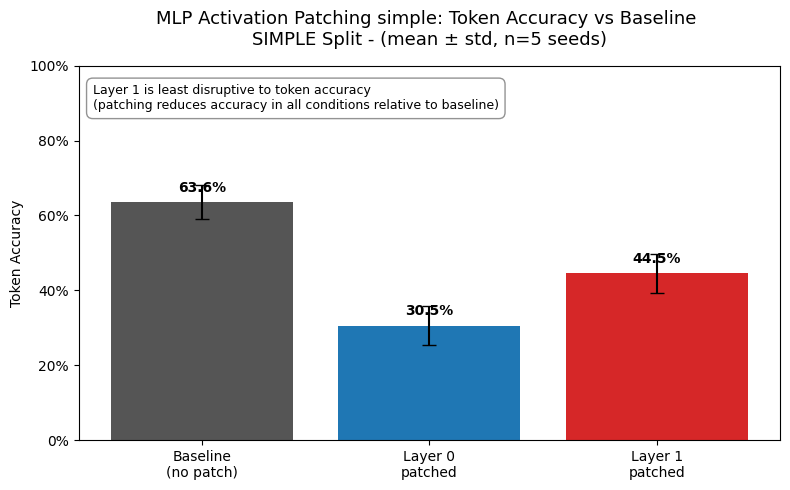


Exact match rate (secondary metric):
  Layer 0: 0.07% ± 0.04%
  Layer 1: 1.44% ± 0.93%


In [43]:
with open("../results/patching/cross_seed_summary_simple.json") as f:
    cross_seed_patching_results = json.load(f)

aggregated_patching_simple = aggregate_patching_results(cross_seed_patching_results)
plot_layer_patching_comparison(aggregated_patching_simple, split="simple")

with open("../results/patching/layer_comparison_aggregate_simple.json", "w") as f:
    json.dump(aggregated_patching_simple, f, indent=2)

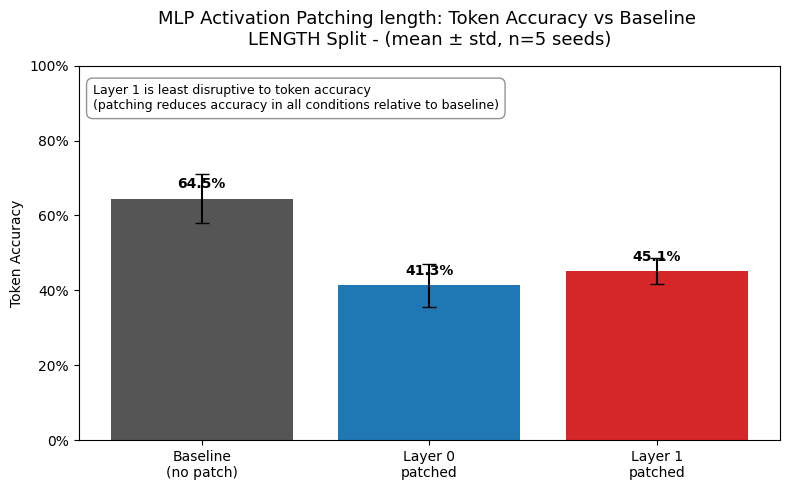


Exact match rate (secondary metric):
  Layer 0: 0.34% ± 0.17%
  Layer 1: 1.63% ± 0.76%


In [44]:
with open("../results/patching/cross_seed_summary_length.json") as f:
    cross_seed_patching_results = json.load(f)

aggregated_patching_length = aggregate_patching_results(cross_seed_patching_results)
plot_layer_patching_comparison(aggregated_patching_length, split="length")

with open("../results/patching/layer_comparison_aggregate_length.json", "w") as f:
    json.dump(aggregated_patching_length, f, indent=2)

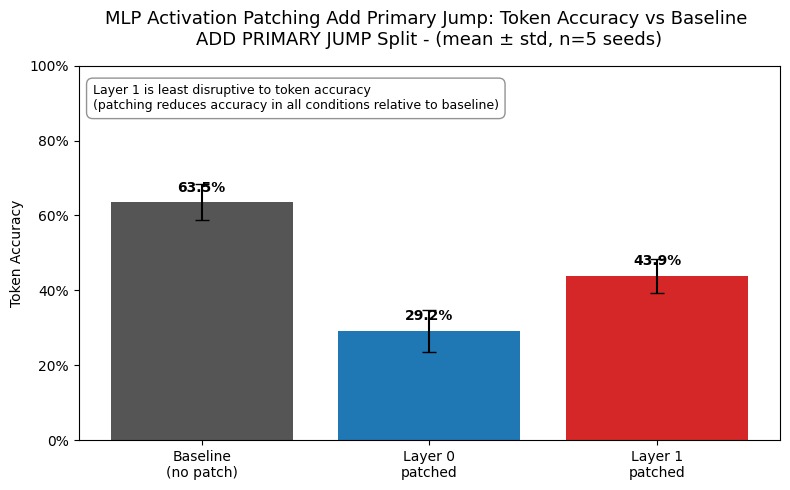


Exact match rate (secondary metric):
  Layer 0: 0.09% ± 0.04%
  Layer 1: 0.84% ± 0.56%


In [45]:
with open("../results/patching/cross_seed_summary_addprim_jump.json") as f:
    cross_seed_patching_results = json.load(f)

aggregated_patching_addprim_jump = aggregate_patching_results(cross_seed_patching_results)
plot_layer_patching_comparison(aggregated_patching_addprim_jump, split="Add Primary Jump")

with open("../results/patching/layer_comparison_aggregate_addprim_jump.json", "w") as f:
    json.dump(aggregated_patching_addprim_jump, f, indent=2)

## 6.Key Findings 

### 6.1 L0H0 Ablation
Ablating L0H0 changes model behavior across all splits but 
produces negative delta (increasing failure cases).

**Interpretation:** L0H0 contributes to structural token tracking
but is not the sole circuit responsible for repetition counting.

### 6.2 MLP Patching Restores Behavior 
Patching average success MLP activations into failure cases 
DECREASES token accuracy across all splits and layers:

- L1 MLP patching: ~20% drop in token accuracy
- L0 MLP patching: ~40% drop in token accuracy

Recovery rates are near-zero (0-4.3%), confirming MLP activations
are highly context-specific and do not transfer across commands.

### 6.4 L1 MLP as Primary Failure Circuit
L1 MLP is consistently more transferable than L0 MLP as L1 patching causes less disruption.

However, neither layer recovers failures meaningfully, suggesting
the failure is distributed rather than localized to one MLP layer.